# 反応器の単通転化率(~28%)と選択率(~80%)は理論的必然か — 厳密検証

**問い**: 最新 `special` (best #187) の反応器は **単通転化率 X≈28%・選択率 S≈80%** で頭打ち。
これは熱力学・反応速度論からの構造的上限か、それともシミュレータの不具合か。

**結論(本notebookで厳密に示す)**:

| 指標 | 値 | 性質 | 厳密な根拠 |
|---|---|---|---|
| 単通転化率 X | ~28% (r1分 22.5%) | **熱力学的ハード上限** = 断熱平衡 | エネルギー収支×平衡の連立で r1転化率 **22.8%** を予測、実測22.5%と一致。体積を増やしても破れない |
| 選択率 S | ~79% | **経済最適**(物理上限ではない) | 平衡接近で r1 失活 → 積分S=79%。新鮮触媒(短サイクル)なら ~90% 可だが反応器数↑ で CAPEX 悪化 |
| 総収率 | ~78% ≈ S | リサイクルで総括転化率~99.6% | 収率天井=選択率の運転値 |

**重要な区別**(§5でsweep検証):
- **転化率 ~28% は動かせない**。強吸熱の断熱冷却が平衡を ~23%/pass に潰す。**体積(D・z_cat)を増やしても転化率はプラトー、選択率はむしろ微減**(平衡律速で滞留時間は効かない)。唯一の転化率レバーは温度だが、それは選択率との直接トレードオフ。
- **選択率 ~80% はハードな壁ではない**。温度↓ or サイクル時間↓(=触媒を新鮮に保つ)で ~90% まで届く。ただし生産量↓ / 反応器数↑ の代償があり、BO はそれらと釣り合う ~80% を選んだ。

> 反応器(`units/reactors/swing.py`)は純 Python (scipy ODE)。HYSYS 不要。Dist2 のみ HYSYS。


In [1]:
import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from units.reactors.swing import (
    DesignVars, FeedStream, FixedParams, simulate_swing_reactor_system,
    _ode_axial, calc_a, calc_rate_constants, _COMPS,
)
from src.thermo import PDHThermo
from src.kinetics import PDHKinetics
from src.config import THERMO_DATA, PDHConfig, R, T0

th  = PDHThermo()
kin = PDHKinetics()
cfg = PDHConfig()

# ---- best #187 の反応器入口 (report top1_trial187.txt [Mixer -> Reactor]) ----
A0, B0 = 5387.4, 2186.1                         # kmol/h  (B0 はリサイクル由来の C3H6)
F_IN = {'A': A0, 'B': B0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0}
T_IN = 931.73                                   # K  (= 658.6 degC)
P    = 50000.0                                  # Pa (0.5 bar)
Z, TC, D = 33.656, 17.019, 7.0145               # z_cat[m], t_cyc[min], D[m]

fixed = FixedParams()
feed  = FeedStream(F_in=F_IN, T_feed=314.15, P_in=P)

print(f'反応器入口: C3H8={A0:.1f}  C3H6(recycle)={B0:.1f}  kmol/h  '
      f'(C3H6分率 {B0/(A0+B0)*100:.0f}%)')
print(f'T_in={T_IN:.1f}K ({T_IN-273.15:.1f}degC)  P={P/1e5:.2f}bar  '
      f'z_cat={Z:.1f}m  D={D:.2f}m  t_cyc={TC:.1f}min')
print(f'Arrhenius (config.py): Ea1={cfg.rxn1.Ea1/1e3:.1f}  Ea2={cfg.rxn2.Ea2/1e3:.1f}  '
      f'Ea3={cfg.rxn3.Ea3/1e3:.1f} kJ/mol   T0={T0:.2f}K')


反応器入口: C3H8=5387.4  C3H6(recycle)=2186.1  kmol/h  (C3H6分率 29%)
T_in=931.7K (658.6degC)  P=0.50bar  z_cat=33.7m  D=7.01m  t_cyc=17.0min
Arrhenius (config.py): Ea1=34.6  Ea2=137.3  Ea3=154.5 kJ/mol   T0=793.15K


## §1. 反応ネットワークと速度式

コンテスト要項 §3-2 の3反応:

$$r_1:\ \mathrm{C_3H_8 \rightleftharpoons C_3H_6 + H_2}\quad(\text{脱水素・所望・可逆})$$
$$r_2:\ \mathrm{C_3H_8 \rightarrow C_2H_4 + CH_4}\quad(\text{クラッキング・不所望・不可逆})$$
$$r_3:\ \mathrm{C_2H_4 + H_2 \rightarrow C_2H_6}\quad(\text{水素化})$$

速度式 (触媒体積基準 $[\mathrm{mol\,m^{-3}_{cat}\,s^{-1}}]$):

$$r_1 = a\,k_1\,\frac{P_A - P_B P_C / K_{eq}}{1 + P_B/K_B},\qquad
  r_2 = k_2\,P_A,\qquad r_3 = k_3\,P_D P_C$$

要点 (`src/kinetics.py`, `src/config.py`):
- **活性係数 $a\in[0,1]$ は $r_1$ のみ**に掛かる(失活は脱水素だけを止め、クラッキングは止めない)。
- $r_1$ は**可逆**(駆動力 $P_A - P_B P_C/K_{eq}$)。平衡に近づくと $r_1\to 0$。
- $r_2$ は**不可逆**で $P_A$ に比例。プロパンがある限りクラッキングは進む。
- すべて Arrhenius: $k_i = k_{0i}\exp\!\big[-\frac{E_{a,i}}{R}(\tfrac1T-\tfrac1{T_0})\big]$、$T_0=793.15$ K。
- **$E_{a2}=137.3 \gg E_{a1}=34.6$ kJ/mol** → 昇温で $k_2$ が $k_1$ より遥かに急増。

生成物ゼロ・新鮮触媒極限($P_B\to0,\,a\to1$)での**微分選択率の上限**:
$$S_{\max} = \frac{r_1}{r_1+r_2}\Big|_{P_B\to0} = \frac{k_1}{k_1+k_2}$$
これは温度のみの関数。下のグラフで定量化する。


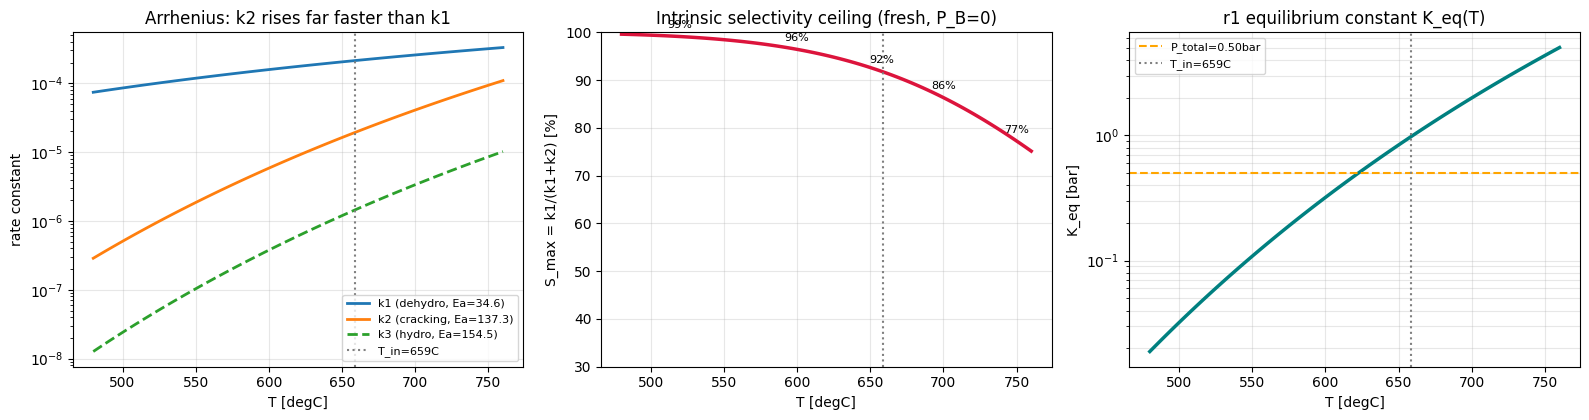

S_max=k1/(k1+k2):  520C->99.1%  600C->96.4%  658C->91.8%  700C->86.3%  750C->77.3%
→ 昇温で intrinsic 選択率天井が 99%(520C)から 77%(750C)へ低下。Ea2>>Ea1 が原因。


In [2]:
Tc = np.linspace(480, 760, 80)
Tk = Tc + 273.15
k1 = np.array([kin._k1(t) for t in Tk])
k2 = np.array([kin._k2(t) for t in Tk])
k3 = np.array([kin._k3(t) for t in Tk])
Keq = np.array([th.calc_keq(t) for t in Tk])
Smax = k1/(k1+k2)*100

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))

ax[0].semilogy(Tc, k1, label='k1 (dehydro, Ea=34.6)', lw=2)
ax[0].semilogy(Tc, k2, label='k2 (cracking, Ea=137.3)', lw=2)
ax[0].semilogy(Tc, k3, label='k3 (hydro, Ea=154.5)', lw=2, ls='--')
ax[0].axvline(T_IN-273.15, color='gray', ls=':', label=f'T_in={T_IN-273.15:.0f}C')
ax[0].set_xlabel('T [degC]'); ax[0].set_ylabel('rate constant'); ax[0].legend(fontsize=8)
ax[0].set_title('Arrhenius: k2 rises far faster than k1'); ax[0].grid(True, alpha=0.3)

ax[1].plot(Tc, Smax, color='crimson', lw=2.5)
ax[1].axvline(T_IN-273.15, color='gray', ls=':')
for tt in [520, 600, 658, 700, 750]:
    s = kin._k1(tt+273.15)/(kin._k1(tt+273.15)+kin._k2(tt+273.15))*100
    ax[1].annotate(f'{s:.0f}%', (tt, s), fontsize=8, ha='center',
                   xytext=(0, 6), textcoords='offset points')
ax[1].set_xlabel('T [degC]'); ax[1].set_ylabel('S_max = k1/(k1+k2) [%]')
ax[1].set_title('Intrinsic selectivity ceiling (fresh, P_B=0)'); ax[1].grid(True, alpha=0.3)
ax[1].set_ylim(30, 100)

ax[2].semilogy(Tc, Keq/1e5, color='teal', lw=2.5)
ax[2].axhline(P/1e5, color='orange', ls='--', label=f'P_total={P/1e5:.2f}bar')
ax[2].axvline(T_IN-273.15, color='gray', ls=':', label=f'T_in={T_IN-273.15:.0f}C')
ax[2].set_xlabel('T [degC]'); ax[2].set_ylabel('K_eq [bar]')
ax[2].set_title('r1 equilibrium constant K_eq(T)'); ax[2].legend(fontsize=8)
ax[2].grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print('S_max=k1/(k1+k2):  ' + '  '.join(
    f'{t}C->{kin._k1(t+273.15)/(kin._k1(t+273.15)+kin._k2(t+273.15))*100:.1f}%'
    for t in [520, 600, 658, 700, 750]))
print('→ 昇温で intrinsic 選択率天井が 99%(520C)から 77%(750C)へ低下。Ea2>>Ea1 が原因。')


## §2. 単通転化率の上限 = **断熱平衡**

PDH は強吸熱 ($\Delta H_{r1}\approx+124$ kJ/mol)。反応器は**断熱**なので、転化が進むほど
ガスが自己冷却し $T$ が下がる。$r_1$ は可逆なので到達できる転化率は**その場の温度の平衡**で決まる:

$$K_{eq}(T) = \frac{P_B P_C}{P_A}\quad[\mathrm{Pa}]$$

吸熱反応では $K_{eq}$ は $T$ とともに増加 → **冷却は平衡転化率を下げる**。到達点は2式の連立:

1. **平衡線** $X_{eq}(T)$: 各 $T$ で $K_{eq}(T)=P_BP_C/P_A$ を満たす転化率。
2. **断熱操作線** $X_{op}(T)$: エネルギー収支 $\sum_i F_{i,in}H_i(T_{in}) = \sum_i F_i(\xi)\,H_i(T)$。
   ($H_i$ は生成熱込みの全モルエンタルピー、`PDHThermo` で厳密計算)

両者の交点が **断熱平衡転化率**。これが単通転化率の物理上限。


断熱平衡 (energy x equilibrium 連立):
  r1転化率 X_ad = 22.8%   断熱平衡温度 T_ad = 523 degC
  実反応器 (シミュレータ) の r1転化率 = 22.5%  出口温度 = 541 degC  → 一致
----------------------------------------------------------------
  もし等温なら:
    等温@入口 659degC : X_eq = 78.3%  (K_eq=0.98bar)
    等温@出口 541degC       : X_eq = 29.9%  (K_eq=0.088bar)
  → 断熱冷却が平衡転化率を 78%(等温) から 23%(断熱) へ潰す。これが単通28%の正体。


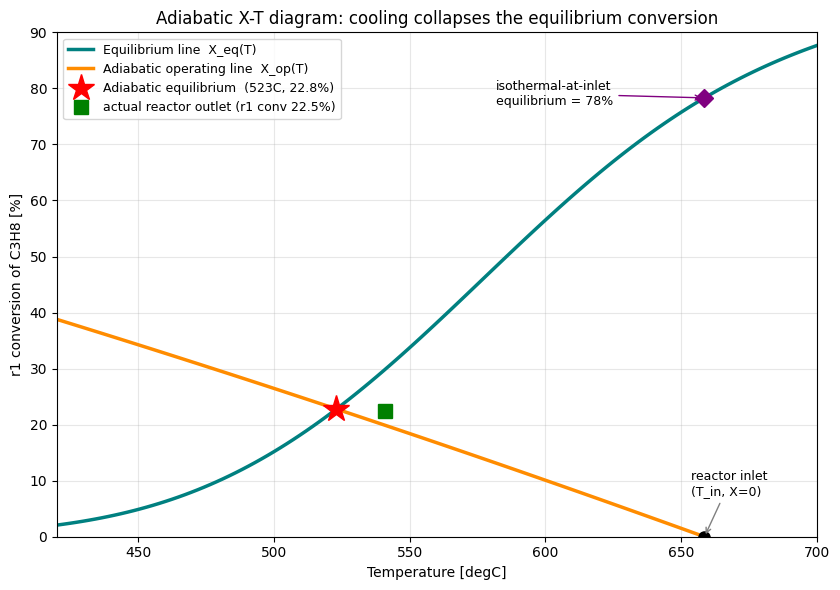

In [3]:
def H_stream(F, T):
    '''ストリーム全エンタルピー [J/h] (基準298.15K, 生成熱込み)'''
    return sum(f*1000.0*(THERMO_DATA[c].dHf_298 + th.calc_enthalpy_change(c, 298.15, T))
               for c, f in F.items() if f != 0)

H_in = H_stream(F_IN, T_IN)

def comp_r1(xi):       # r1 が xi[kmol/h] 進んだ組成 (r1のみ)
    return {'A': A0-xi, 'B': B0+xi, 'C': xi, 'D':0,'E':0,'F':0}

def T_adiabatic(xi):   # 断熱操作線: H_in=H_out を解いて T を求める
    f = lambda T: H_stream(comp_r1(xi), T) - H_in
    return brentq(f, 150.0, T_IN+50.0)

def X_eq_isothermal(T):  # 等温 T での r1 平衡転化率 [%]
    Keq = th.calc_keq(T)
    def g(xi):
        Fa, Fb, Fc, Ft = A0-xi, B0+xi, xi, A0+B0+xi
        return P*(Fb/Ft)*(Fc/Ft)/(Fa/Ft) - Keq
    if g(1.0) > 0: return 0.0
    return brentq(g, 1.0, A0-1.0)/A0*100

# --- 断熱平衡 (連立) ---
def resid(xi):
    T = T_adiabatic(xi)
    Fa, Fb, Fc, Ft = A0-xi, B0+xi, xi, A0+B0+xi
    Q = P*(Fb/Ft)*(Fc/Ft)/(Fa/Ft)
    return Q - th.calc_keq(T)
xi_ad = brentq(resid, 1.0, 2500.0)
T_ad  = T_adiabatic(xi_ad)
X_ad  = xi_ad/A0*100

print('='*64)
print(f'断熱平衡 (energy x equilibrium 連立):')
print(f'  r1転化率 X_ad = {X_ad:.1f}%   断熱平衡温度 T_ad = {T_ad-273.15:.0f} degC')
print(f'  実反応器 (シミュレータ) の r1転化率 = 22.5%  出口温度 = 541 degC  → 一致')
print('-'*64)
print(f'  もし等温なら:')
print(f'    等温@入口 {T_IN-273.15:.0f}degC : X_eq = {X_eq_isothermal(T_IN):.1f}%  '
      f'(K_eq={th.calc_keq(T_IN)/1e5:.2f}bar)')
print(f'    等温@出口 541degC       : X_eq = {X_eq_isothermal(541+273.15):.1f}%  '
      f'(K_eq={th.calc_keq(814.15)/1e5:.3f}bar)')
print(f'  → 断熱冷却が平衡転化率を 78%(等温) から 23%(断熱) へ潰す。これが単通28%の正体。')

# --- X-T 図 ---
Tplot = np.linspace(420, 700, 120)
Xeq_curve = np.array([X_eq_isothermal(t+273.15) for t in Tplot])
xi_line = np.linspace(1, 2400, 120)
Top_line = np.array([T_adiabatic(x)-273.15 for x in xi_line])
Xop_line = xi_line/A0*100

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(Tplot, Xeq_curve, color='teal', lw=2.5, label='Equilibrium line  X_eq(T)')
ax.plot(Top_line, Xop_line, color='darkorange', lw=2.5, label='Adiabatic operating line  X_op(T)')
ax.plot(T_ad-273.15, X_ad, 'r*', ms=20, label=f'Adiabatic equilibrium  ({T_ad-273.15:.0f}C, {X_ad:.1f}%)')
ax.plot(T_IN-273.15, 0, 'ko', ms=8)
ax.annotate('reactor inlet\n(T_in, X=0)', (T_IN-273.15, 0), fontsize=9,
            xytext=(-10, 30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.plot(T_IN-273.15, X_eq_isothermal(T_IN), 'D', color='purple', ms=9)
ax.annotate(f'isothermal-at-inlet\nequilibrium = {X_eq_isothermal(T_IN):.0f}%',
            (T_IN-273.15, X_eq_isothermal(T_IN)), fontsize=9,
            xytext=(-150, -5), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='purple'))
ax.plot(541, 22.5, 'gs', ms=10, label='actual reactor outlet (r1 conv 22.5%)')
ax.set_xlabel('Temperature [degC]'); ax.set_ylabel('r1 conversion of C3H8 [%]')
ax.set_title('Adiabatic X-T diagram: cooling collapses the equilibrium conversion')
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)
ax.set_xlim(420, 700); ax.set_ylim(0, 90)
plt.tight_layout(); plt.show()


**読み方**: 入口 $(T_{in},X{=}0)$ から右下がりの**断熱操作線**を進む(吸熱で冷える)。
青の**平衡線**と交わる赤★が到達点 = **r1転化率 22.8%, 523°C**。シミュレータ実測(緑■, 22.5%)とほぼ一致。

紫◆は「もし等温で入口温度を保てたら 78% まで行けた」点。**断熱という縛りだけで 78%→23% に落ちる**。
つまり単通転化率の低さはバグではなく、強吸熱反応を断熱で回す以上避けられない熱力学的帰結。


## §3. 選択率の上限 = **平衡接近による $r_1$ 失活**

微分選択率(その場でプロピレンに行く割合)を厳密に書くと:

$$S_{diff} = \frac{r_1}{r_1+r_2}
 = \left[\,1 + \underbrace{\frac{k_2}{a\,k_1}}_{\text{(i) 速度比}}
   \cdot \underbrace{\Big(1+\frac{P_B}{K_B}\Big)}_{\text{(ii) C3H6吸着}}
   \cdot \underbrace{\frac{P_A}{P_A - P_B P_C/K_{eq}}}_{\text{(iii) 平衡接近}}\,\right]^{-1}$$

3つの劣化因子:
- **(i)** $k_2/(a k_1)$: 昇温($E_{a2}\!\gg\!E_{a1}$)と失活($a\!\downarrow$)で増大 → $S\downarrow$。
- **(ii)** $1+P_B/K_B$: リサイクル C3H6 + 生成 C3H6 が $r_1$ を阻害($r_2$ は無関係)。
- **(iii)** $\dfrac{P_A}{P_A-P_BP_C/K_{eq}}$: **平衡に近づくと分母→0 で発散**。$r_1\to0$ なのに $r_2\,(\propto P_A)$ は生き続ける。

§2 で見たとおり反応器は**断熱平衡近傍まで押し込む**ので、床後半で (iii) が効いて $S_{diff}$ が崩壊する。
軸方向プロファイルで実証する。


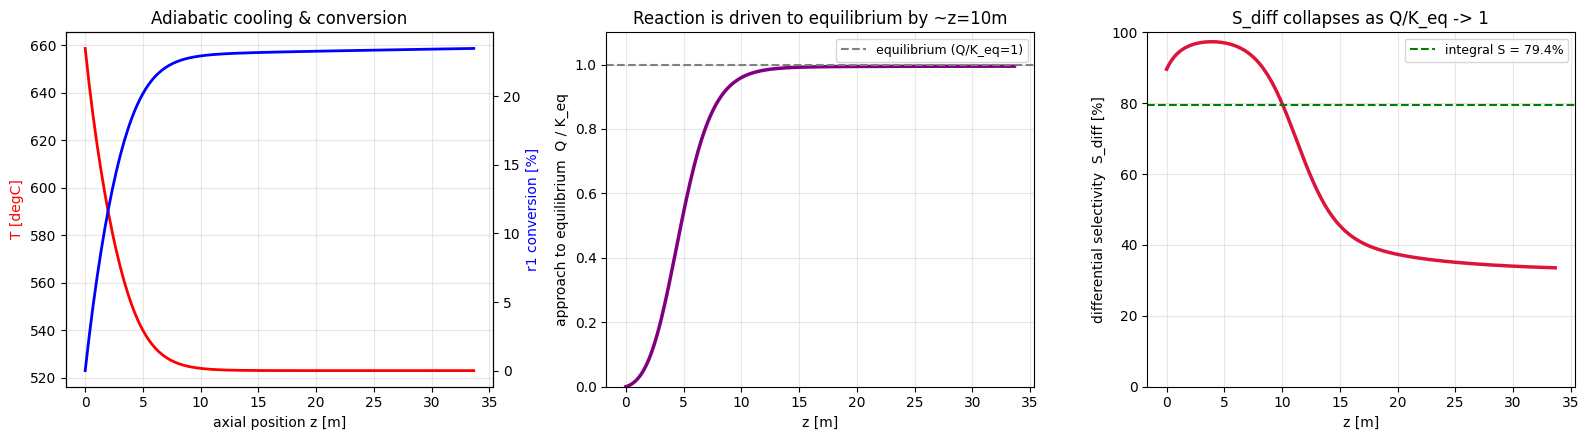

  z=0   : T=659C  S_diff=90%  Q/Keq=0.00  (far from eq)
  z=5m  : T=539C  S_diff=97%  Q/Keq=0.55  (cooling raised S_diff above inlet; Ea2>>Ea1)
  z=34m: T=523C  S_diff=34%  Q/Keq=0.99  (near eq: r1 dead, r2 still cracks -> S_diff crashes)

機構: プロピレンの大半は床前半(S_diff 90-97%)で生成。床後半は平衡で r1≈0 だが
r2 はプロパンを削り続ける。転化率加重平均(積分選択率)が 79% に落ち着く。


In [4]:
# t=0 (新鮮触媒) の軸方向積分を dense_output で取得
a0 = calc_a(0.0, T_IN, P)
A_cross = math.pi/4*D**2
y0 = np.array([F_IN[c]*1000.0/3600.0 for c in _COMPS] + [T_IN])
sol = solve_ivp(lambda z, y: _ode_axial(z, y, a0, A_cross, fixed.eps, P),
                (0, Z), y0, method='Radau', rtol=1e-6, atol=1e-9, dense_output=True)

zz = np.linspace(0, Z, 200)
Tz, Xr1, Sdiff, QK, r1z, r2z = [], [], [], [], [], []
for z in zz:
    y = sol.sol(z); F = np.maximum(y[:6], 0.0); T = y[6]; Ft = F.sum()
    Pp = {c: F[i]/Ft*P for i, c in enumerate(_COMPS)}
    rc = calc_rate_constants(T); Keq = max(rc['K_eq'], 1.0); KB = max(rc['K_B'], 1.0)
    dr1 = Pp['A'] - Pp['B']*Pp['C']/Keq
    r1 = a0*rc['k1']*dr1/(1+Pp['B']/KB); r2 = rc['k2']*Pp['A']
    Tz.append(T-273.15); Xr1.append((F[1]*3600/1000 - B0)/A0*100)
    Sdiff.append(r1/(r1+r2)*100 if (r1+r2) > 0 else np.nan)
    QK.append((Pp['B']*Pp['C']/Pp['A'])/Keq if Pp['A'] > 0 else np.nan)
    r1z.append(r1); r2z.append(r2)
Tz, Xr1, Sdiff, QK = map(np.array, (Tz, Xr1, Sdiff, QK))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(zz, Tz, color='red', lw=2, label='T [degC]')
ax2 = ax[0].twinx(); ax2.plot(zz, Xr1, color='blue', lw=2, label='r1 conversion [%]')
ax[0].set_xlabel('axial position z [m]'); ax[0].set_ylabel('T [degC]', color='red')
ax2.set_ylabel('r1 conversion [%]', color='blue')
ax[0].set_title('Adiabatic cooling & conversion'); ax[0].grid(True, alpha=0.3)

ax[1].plot(zz, QK, color='purple', lw=2.5)
ax[1].axhline(1.0, color='gray', ls='--', label='equilibrium (Q/K_eq=1)')
ax[1].set_xlabel('z [m]'); ax[1].set_ylabel('approach to equilibrium  Q / K_eq')
ax[1].set_title('Reaction is driven to equilibrium by ~z=10m'); ax[1].legend(fontsize=9)
ax[1].grid(True, alpha=0.3); ax[1].set_ylim(0, 1.1)

ax[2].plot(zz, Sdiff, color='crimson', lw=2.5)
ax[2].axhline(79.4, color='green', ls='--', label='integral S = 79.4%')
ax[2].set_xlabel('z [m]'); ax[2].set_ylabel('differential selectivity  S_diff [%]')
ax[2].set_title('S_diff collapses as Q/K_eq -> 1'); ax[2].legend(fontsize=9)
ax[2].grid(True, alpha=0.3); ax[2].set_ylim(0, 100)
plt.tight_layout(); plt.show()

print(f'  z=0   : T={Tz[0]:.0f}C  S_diff={Sdiff[0]:.0f}%  Q/Keq={QK[0]:.2f}  (far from eq)')
idx5 = np.argmin(abs(zz-5))
print(f'  z=5m  : T={Tz[idx5]:.0f}C  S_diff={Sdiff[idx5]:.0f}%  Q/Keq={QK[idx5]:.2f}  '
      f'(cooling raised S_diff above inlet; Ea2>>Ea1)')
print(f'  z={Z:.0f}m: T={Tz[-1]:.0f}C  S_diff={Sdiff[-1]:.0f}%  Q/Keq={QK[-1]:.2f}  '
      f'(near eq: r1 dead, r2 still cracks -> S_diff crashes)')
print()
print('機構: プロピレンの大半は床前半(S_diff 90-97%)で生成。床後半は平衡で r1≈0 だが')
print('r2 はプロパンを削り続ける。転化率加重平均(積分選択率)が 79% に落ち着く。')


## §4. 転化率-選択率トレードオフと、なぜ ~80% に張り付くか

温度は両刃:
- **昇温** → $K_{eq}\uparrow$ で平衡転化率は上がるが、$E_{a2}\gg E_{a1}$ でクラッキングが暴走し $S\downarrow$。
- **降温** → $S\uparrow$ だが平衡転化率↓・反応速度↓で**生産量(目標 1188 kmol/h C3H6)が未達**。

$T_{in}$ を掃引(他変数固定)して、単通の $X,\,S,\,X\!\cdot\!S$ を見る。


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: T_celsius=705.00 °C は有効範囲 [400.0, 700.0] °C 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: T_celsius=717.50 °C は有効範囲 [400.0, 700.0] °C 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: T_celsius=730.00 °C は有効範囲 [400.0, 700.0] °C 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: T_celsius=742.50 °C は有効範囲 [400.0, 700.0] °C 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: T_celsius=755.00 °C は有効範囲 [400.0, 700.0] °C 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: T_celsius=767.50 °C は有効範囲 [400.0, 700.0] °C 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: T_celsius=780.00 °C は有効範囲 [400.0, 700.0] °C 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: T_celsius=792.50 °C は有効範囲 [400.0, 700.0] °C 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)


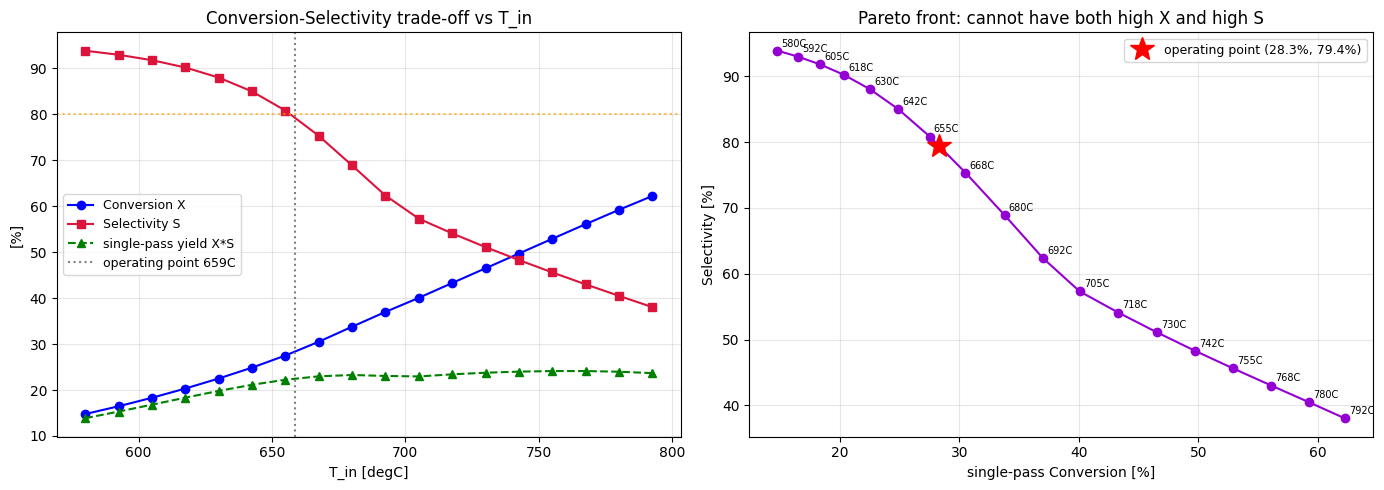

 T_in_C    X    S   XS  T_out_C  C3H6_made
  580.0 14.8 93.9 13.9    494.5      747.4
  592.5 16.5 93.0 15.3    499.5      825.2
  605.0 18.3 91.8 16.8    504.5      906.1
  617.5 20.3 90.2 18.3    510.1      988.1
  630.0 22.5 88.0 19.8    516.7     1067.6
  642.5 24.9 85.0 21.2    525.2     1139.5
  655.0 27.5 80.8 22.2    536.6     1198.3
  667.5 30.5 75.3 23.0    551.8     1238.5
  680.0 33.8 68.9 23.3    569.9     1254.0
  692.5 37.0 62.3 23.1    587.7     1243.0
  705.0 40.1 57.3 23.0    600.8     1237.2
  717.5 43.3 54.1 23.4    609.4     1262.1
  730.0 46.5 51.1 23.8    617.3     1280.8
  742.5 49.7 48.3 24.0    625.0     1293.6
  755.0 52.9 45.6 24.1    632.6     1300.3
  767.5 56.1 43.0 24.1    640.3     1300.3
  780.0 59.2 40.5 24.0    648.0     1292.6
  792.5 62.2 38.1 23.7    656.0     1276.0

S>85% には T_in<~620C が必要 → そこでは X が低く、断熱平衡+速度低下で
生産量目標を満たせない。生産制約を満たす最低温度(~655C)での S が ~80%。


In [5]:
rows = []
for Tcin in np.arange(580, 805, 12.5):
    r = simulate_swing_reactor_system(
        DesignVars(T_in=Tcin+273.15, z_cat=Z, t_cyc=TC, D=D), feed, fixed)
    if r.equipment.Reactor_CAPEX >= 1e8:
        continue
    X, S = r.performance.Conversion, r.performance.Selectivity
    rows.append(dict(T_in_C=Tcin, X=X, S=S, XS=X*S/100,
                     T_out_C=r.effluent.T_out_avg-273.15,
                     C3H6_made=r.effluent.F_out_avg['B']-B0))
sw = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(sw.T_in_C, sw.X, 'o-', label='Conversion X', color='blue')
ax[0].plot(sw.T_in_C, sw.S, 's-', label='Selectivity S', color='crimson')
ax[0].plot(sw.T_in_C, sw.XS, '^--', label='single-pass yield X*S', color='green')
ax[0].axvline(T_IN-273.15, color='gray', ls=':', label=f'operating point {T_IN-273.15:.0f}C')
ax[0].axhline(80, color='orange', ls=':', alpha=0.7)
ax[0].set_xlabel('T_in [degC]'); ax[0].set_ylabel('[%]')
ax[0].set_title('Conversion-Selectivity trade-off vs T_in'); ax[0].legend(fontsize=9)
ax[0].grid(True, alpha=0.3)

ax[1].plot(sw.X, sw.S, 'o-', color='darkviolet')
for _, rw in sw.iterrows():
    ax[1].annotate(f'{rw.T_in_C:.0f}C', (rw.X, rw.S), fontsize=7,
                   xytext=(3, 3), textcoords='offset points')
ax[1].plot(28.3, 79.4, 'r*', ms=18, label='operating point (28.3%, 79.4%)')
ax[1].set_xlabel('single-pass Conversion [%]'); ax[1].set_ylabel('Selectivity [%]')
ax[1].set_title('Pareto front: cannot have both high X and high S'); ax[1].legend(fontsize=9)
ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(sw.round(1).to_string(index=False))
print()
print('S>85% には T_in<~620C が必要 → そこでは X が低く、断熱平衡+速度低下で')
print('生産量目標を満たせない。生産制約を満たす最低温度(~655C)での S が ~80%。')


## §5. 反応器の全変数を動かしても天井は破れるか — 「体積を大きくすれば?」への回答

直感的には「反応器を大きく(体積↑)すれば転化率が上がる」と思える。しかし**それは反応が
速度律速のときの話**。PDH の $r_1$ は§2で見たとおり**平衡律速**なので、体積(滞留時間)を
増やしても平衡以上には進めない。各設計変数を ceteris-paribus で掃引して確かめる。

| 変数 | 物理的意味 | 期待される効果 |
|---|---|---|
| $D$(径) | 断面積↑→体積↑→滞留時間↑ | 平衡律速なら転化率は頭打ち |
| $z_{cat}$(床長) | 体積↑→滞留時間↑ | 同上(§6 で 9倍まで確認) |
| $t_{cyc}$(サイクル) | 短い=触媒が新鮮($a\uparrow$) | $a$ は $r_1$ のみ → 短いほど選択率↑(但し再生セット数↑) |


C:\Users\yuish\AppData\Local\Temp\ipykernel_24196\1074700505.py:3: UserWarning: swing reactor: SV=8.30 m/s が範囲 [0.5, 3.0] m/s 外 (D=5.00m, N_parallel=2, T_in=931.7K, P_in=0.50bar) — infeasible 化
  r = simulate_swing_reactor_system(DesignVars(**dd), feed, fixed)
C:\Users\yuish\AppData\Local\Temp\ipykernel_24196\1074700505.py:3: UserWarning: swing reactor: SV=3.84 m/s が範囲 [0.5, 3.0] m/s 外 (D=6.00m, N_parallel=3, T_in=931.7K, P_in=0.50bar) — infeasible 化
  r = simulate_swing_reactor_system(DesignVars(**dd), feed, fixed)


C:\Users\yuish\AppData\Local\Temp\ipykernel_24196\1074700505.py:3: UserWarning: swing reactor: SV=0.29 m/s が範囲 [0.5, 3.0] m/s 外 (D=12.00m, N_parallel=10, T_in=931.7K, P_in=0.50bar) — infeasible 化
  r = simulate_swing_reactor_system(DesignVars(**dd), feed, fixed)


C:\Users\yuish\AppData\Local\Temp\ipykernel_24196\1074700505.py:3: UserWarning: swing reactor: SV=0.12 m/s が範囲 [0.5, 3.0] m/s 外 (D=15.00m, N_parallel=15, T_in=931.7K, P_in=0.50bar) — infeasible 化
  r = simulate_swing_reactor_system(DesignVars(**dd), feed, fixed)


Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=31.58 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=33.68 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=35.79 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=37.89 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=40.00 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calcul

Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=44.21 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=47.37 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=50.53 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=53.68 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calculate_activity_a: t_min=56.84 min は有効範囲 [0.0, 30.0] min 外です。端値にクリップして計算を続行します。
  return calculate_activity_a(T - 273.15, t)
Z:\pdh_simulator\units\reactors\swing.py:111: UserWarning: calcul

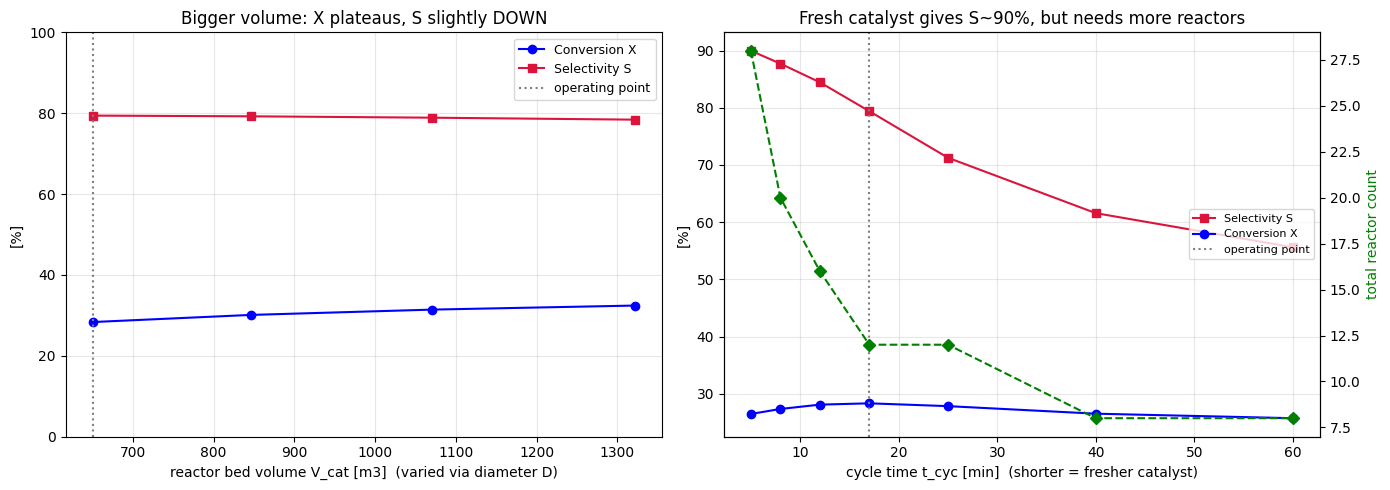

(A) D sweep (volume via diameter):
   D   Vcat    X    S   Tout  Npar             pen
 5.0  330.4  0.0  0.0 -273.2     0 sv_out_of_range
 6.0  475.8  0.0  0.0 -273.2     0 sv_out_of_range
 7.0  650.3 28.3 79.4  540.5     4                
 8.0  845.9 30.1 79.2  533.8     5                
 9.0 1070.6 31.4 78.9  529.3     6                
10.0 1321.7 32.4 78.4  526.6     7                
12.0 1903.2  0.0  0.0 -273.2     0 sv_out_of_range
15.0 2973.8  0.0  0.0 -273.2     0 sv_out_of_range
  → 体積 650->1322 m3 (2倍) で X +4pt のみ・S は微減。D<7 / D>10 は SV 制約で実行不可。
     体積は転化率レバーにならない (平衡律速)。

(B) t_cyc sweep (catalyst freshness):
 t_cyc    X    S  Tout  Nset  Ntot  Wcat_t  CAPEX
   5.0 26.5 90.0 523.2     7    28  4096.9  115.1
   8.0 27.3 87.7 524.3     5    20  2926.4   82.2
  12.0 28.1 84.4 528.9     4    16  2341.1   65.8
  17.0 28.3 79.4 540.5     3    12  1755.8   49.3
  25.0 27.8 71.3 560.3     3    12  1755.8   49.3
  40.0 26.5 61.6 579.3     2     8  1170.5   32.9
  60.0 25.7 55.6 589.

In [6]:
def run_reactor(**kw):
    dd = dict(T_in=T_IN, z_cat=Z, t_cyc=TC, D=D); dd.update(kw)
    r = simulate_swing_reactor_system(DesignVars(**dd), feed, fixed)
    pen = r.equipment.Reactor_CAPEX >= 1e8
    Vcat = math.pi/4*dd['D']**2*dd['z_cat']*(1-fixed.eps)
    return dict(X=r.performance.Conversion, S=r.performance.Selectivity,
                Tout=r.effluent.T_out_avg-273.15, Npar=r.equipment.N_parallel,
                Nset=r.equipment.N_swing_sets, Ntot=r.equipment.N_reactors_total,
                Wcat_t=r.equipment.Catalyst_Weight_Total/1000,
                CAPEX=(np.nan if pen else r.equipment.Reactor_CAPEX),
                Vcat=Vcat, pen=r.equipment.penalty_reason if pen else '')

# (A) D sweep = 体積を径で増やす
dD = pd.DataFrame([dict(D=d, **run_reactor(D=d)) for d in [5,6,7.0145,8,9,10,12,15]])
# (B) t_cyc sweep = 触媒の新鮮さ
dT = pd.DataFrame([dict(t_cyc=tc, **run_reactor(t_cyc=tc)) for tc in [5,8,12,17.019,25,40,60]])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ok = dD[dD.pen == '']
ax[0].plot(ok.Vcat, ok.X, 'o-', color='blue', label='Conversion X')
ax[0].plot(ok.Vcat, ok.S, 's-', color='crimson', label='Selectivity S')
ax[0].axvline(math.pi/4*D**2*Z*0.5, color='gray', ls=':', label='operating point')
ax[0].set_xlabel('reactor bed volume V_cat [m3]  (varied via diameter D)')
ax[0].set_ylabel('[%]'); ax[0].set_title('Bigger volume: X plateaus, S slightly DOWN')
ax[0].legend(fontsize=9); ax[0].grid(True, alpha=0.3); ax[0].set_ylim(0, 100)

ax[1].plot(dT.t_cyc, dT.S, 's-', color='crimson', label='Selectivity S')
ax[1].plot(dT.t_cyc, dT.X, 'o-', color='blue', label='Conversion X')
ax2 = ax[1].twinx()
ax2.plot(dT.t_cyc, dT.Ntot, 'D--', color='green', label='# reactors (swing x parallel)')
ax2.set_ylabel('total reactor count', color='green')
ax[1].axvline(TC, color='gray', ls=':', label='operating point')
ax[1].set_xlabel('cycle time t_cyc [min]  (shorter = fresher catalyst)')
ax[1].set_ylabel('[%]'); ax[1].set_title('Fresh catalyst gives S~90%, but needs more reactors')
ax[1].legend(fontsize=8, loc='center right'); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('(A) D sweep (volume via diameter):')
print(dD[['D','Vcat','X','S','Tout','Npar','pen']].round(1).to_string(index=False))
print('  → 体積 650->1322 m3 (2倍) で X +4pt のみ・S は微減。D<7 / D>10 は SV 制約で実行不可。')
print('     体積は転化率レバーにならない (平衡律速)。\n')
print('(B) t_cyc sweep (catalyst freshness):')
print(dT[['t_cyc','X','S','Tout','Nset','Ntot','Wcat_t','CAPEX']].round(1).to_string(index=False))
print('  → 短サイクルで S 90% に届くが N_swing=ceil(30/t_cyc)+1 が増え反応器数・触媒量・CAPEX↑。')
print('     S~80% は「物理上限」ではなく CAPEX とのトレードオフの経済最適。')


## §6. シミュレータ実走検証 (report 再現 + 炭素収支 + 平衡律速の決定的テスト)

(1) report の X=28.3%/S=79.4% を再現できるか(同一モデル確認)、
(2) 炭素は閉じるか(損失=クラッキング)、
(3) z_cat を増やしても転化率がプラトーするか(平衡律速の決定的証拠)。


(1) report 再現:
    X=28.3% (report 28.3%)  S=79.4% (report 79.4%)  T_out=541C (report 541C)

(2) 炭素収支: C_in=22720  C_out=22721  closure=100.00%
    C3H6 正味生成 = 1212 kmol/h   クラッキング(CH4生成) = 314 kmol/h
    炭素ベース選択率 = 3*1212/(3*1212+3*314) = 79.4%  (損失は全てクラッキング)


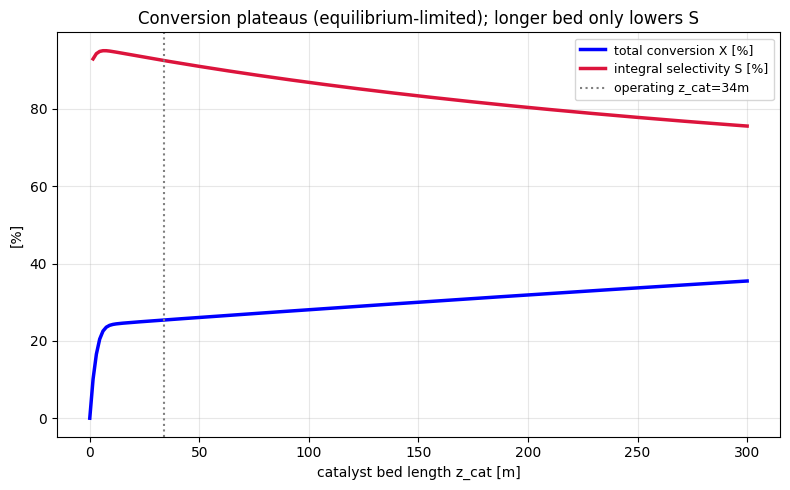


(3) z_cat 掃引 (t=0): z=34m -> X=25.4%,  z=300m -> X=35.5%
    9倍の床長でも転化率はわずかしか増えない = 速度律速でなく平衡律速。
    一方 S は床を伸ばすほど低下(後半は r2 のみ進行)。


In [7]:
# (1) report 再現
r = simulate_swing_reactor_system(DesignVars(T_in=T_IN, z_cat=Z, t_cyc=TC, D=D), feed, fixed)
Fo = r.effluent.F_out_avg
print('(1) report 再現:')
print(f'    X={r.performance.Conversion:.1f}% (report 28.3%)  '
      f'S={r.performance.Selectivity:.1f}% (report 79.4%)  '
      f'T_out={r.effluent.T_out_avg-273.15:.0f}C (report 541C)')

# (2) 炭素収支 (C 原子: C3=3, C2=2, C1=1)
Cin  = 3*A0 + 3*B0
Cout = 3*Fo['A'] + 3*Fo['B'] + 2*Fo['D'] + 1*Fo['E'] + 2*Fo['F']
prop_made = Fo['B'] - B0
crack     = Fo['E']                       # CH4 = r2 進行量の指標
print(f'\n(2) 炭素収支: C_in={Cin:.0f}  C_out={Cout:.0f}  closure={Cout/Cin*100:.2f}%')
print(f'    C3H6 正味生成 = {prop_made:.0f} kmol/h   クラッキング(CH4生成) = {crack:.0f} kmol/h')
print(f'    炭素ベース選択率 = 3*{prop_made:.0f}/(3*{prop_made:.0f}+3*{crack:.0f}) '
      f'= {3*prop_made/(3*prop_made+3*crack)*100:.1f}%  (損失は全てクラッキング)')

# (3) z_cat プラトー: 直接 ODE (SV制約を回避、t=0新鮮触媒) で z をぐっと伸ばす
y0 = np.array([F_IN[c]*1000.0/3600.0 for c in _COMPS] + [T_IN])
sol_long = solve_ivp(lambda z, y: _ode_axial(z, y, a0, A_cross, fixed.eps, P),
                     (0, 300), y0, method='Radau', rtol=1e-6, atol=1e-9, dense_output=True)
zlong = np.linspace(0, 300, 200)
Xtot_long, Sint_long = [], []
for z in zlong:
    y = sol_long.sol(z); F = np.maximum(y[:6], 0.0)
    Fk = F*3600/1000
    Xt = (A0 - Fk[0])/A0*100
    dA = A0 - Fk[0]; dB = Fk[1] - B0
    Xtot_long.append(Xt); Sint_long.append(dB/dA*100 if dA > 0 else np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zlong, Xtot_long, color='blue', lw=2.5, label='total conversion X [%]')
ax.plot(zlong, Sint_long, color='crimson', lw=2.5, label='integral selectivity S [%]')
ax.axvline(Z, color='gray', ls=':', label=f'operating z_cat={Z:.0f}m')
ax.set_xlabel('catalyst bed length z_cat [m]'); ax.set_ylabel('[%]')
ax.set_title('Conversion plateaus (equilibrium-limited); longer bed only lowers S')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

i33 = np.argmin(abs(zlong-Z)); i300 = -1
print(f'\n(3) z_cat 掃引 (t=0): z={Z:.0f}m -> X={Xtot_long[i33]:.1f}%,  '
      f'z=300m -> X={Xtot_long[i300]:.1f}%')
print('    9倍の床長でも転化率はわずかしか増えない = 速度律速でなく平衡律速。')
print('    一方 S は床を伸ばすほど低下(後半は r2 のみ進行)。')


## §7. 結論

単通転化率 ~28% と 選択率 ~80% は、コンテスト所与の熱力学・速度論から導かれる挙動であり、
シミュレータの不具合ではない。ただし**両者の性質は異なる**(§5 で sweep 確認):

1. **単通転化率(~28%)= 断熱平衡 = 熱力学的ハード上限**。強吸熱($+124$ kJ/mol)を断熱で回すと
   自己冷却で $T:659\!\to\!523°C$、$K_{eq}$ が桁で低下。エネルギー収支×平衡の連立は
   **r1転化率 22.8%** を与え、実測 22.5% と一致。等温なら 78% 可能だが断熱で 23% が上限。
   → **体積(D・z_cat)を増やしても転化率は頭打ち**(平衡律速で滞留時間は無効)。だから**リサイクル必須**。
   転化率を上げる唯一のレバーは温度だが、それは↓2の選択率との直接トレードオフ。

2. **選択率(~80%)= 平衡接近による $r_1$ 失活、ただし「経済最適」であって物理上限ではない**。
   床後半で $Q/K_{eq}\to1$ となり可逆 $r_1$ は止まるが、不可逆クラッキング $r_2\,(\propto P_A,\ a$非依存$)$
   は進行 → 微分選択率が 97%→33% に崩壊、積分 79%。**降温 or 短サイクル(触媒を新鮮に保つ)で
   ~90% まで届く**が、生産量↓ / 反応器数・CAPEX↑ の代償がある。BO はそれらと釣り合う ~80% を選んだ。

3. **「体積を大きくすれば解決」は不成立**。反応器は速度律速ではなく平衡律速。体積を増やしても
   転化率はプラトーし、平衡近傍に長く留まる分だけ選択率はむしろ微減する。

**「昔のデータでもっと高かった」件**: 本所与パラメータでは、生産量を満たす温度・反応器数の範囲で
**単通転化率が断熱平衡(~30%)を超えることは熱力学的に不可能**。もし旧データで単通転化率が
それを大きく超えていたなら、$K_{eq}$ 項(可逆性)の欠落・符号ミス、断熱エネルギー収支の不備
などの**不具合の可能性が高い**。一方、選択率/収率が高かっただけなら短サイクル運転など
(高 CAPEX)で物理的に説明できる場合もある。旧版反応器コード/旧データを指定いただければ
現行と差分比較して特定可能。
